In [ ]:
#!/usr/bin/env python
import os,sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import glob
import re
import math
import glob
import warnings
# Suppress all warnings
warnings.filterwarnings("ignore")
sys.stdout = open(os.devnull,'w')


In [19]:
####### check logs
dropbox_root='/media/plotnips/sdd1/Dropbox'
# dropbox_root='/Users/pavelplotnitskii/Dropbox'
folder_milanX=os.path.join(dropbox_root,'Apps/download_to_laptop/rtm_tests_milanx/')

In [20]:
def read_sb_data(filename):
    times=[]
    giga_points=[]
    giga_flops=[]
    point_updates=[]
    flops=[]
    method=[]
    grids=[]
    cores=[]
    cb_size=[]
    cb_x=[]
    cb_y=[]
    cb_z=[]
    thx=[]
    thy=[]
    thz=[]
    tdim=[]
    numwf=[]
    ##################
    tmp_time=math.nan
    tmp_giga_points=math.nan
    tmp_giga_flops=math.nan
    tmp_point_updates=math.nan
    tmp_flops=math.nan
    tmp_grid=math.nan
    tmp_cb_x=math.nan
    tmp_cb_y=math.nan
    tmp_cb_z=math.nan
    tmp_thx=math.nan
    tmp_thy=math.nan
    tmp_thz=math.nan
    tmp_tdim=math.nan
    tmp_numwf=math.nan
    ##################
    ###### Parse files and aggregate them into the dataframe #######################
    print(os.getcwd())
    if not os.path.exists(filename):
        print(f"Warning: File '{filename}' not found. Skipping.")
        return None
    with open(os.path.join(filename),'r') as file:
        previous_line=''
        for line in file:
            if ('START SB KERNEL' in line) or ('START TB KERNEL' in line):
                tmp_time=math.nan
                tmp_giga_points=math.nan
                tmp_giga_flops=math.nan
                tmp_point_updates=math.nan
                tmp_flops=math.nan
                tmp_grid=math.nan
                tmp_cb_x=math.nan
                tmp_cb_y=math.nan
                tmp_cb_z=math.nan
                tmp_thx=math.nan
                tmp_thy=math.nan
                tmp_thz=math.nan
                tmp_tdim=math.nan
                tmp_numwf=math.nan
            if 'GRID' in line and issubclass(type(tmp_grid), str)==False:
                    tmp_grid=(line.split('GRID')[-1])
                    tmp_grid=(tmp_grid.split('\n')[0])
                    tmp_grid=tmp_grid.strip()
            elif 'ELAPSED TIME (s)' in line and np.isnan(tmp_time):
                tmp_time=(float(line.split()[-1]))
            elif 'GIGA POINT / s' in line and np.isnan(tmp_giga_points):
                tmp_giga_points=(float(line.split()[-1]))
            elif 'GIGA FLOP / s' in line and np.isnan(tmp_giga_flops):
                tmp_giga_flops=(float(line.split()[-1]))
            elif '# POINT UPDATES' in line and np.isnan(tmp_point_updates):
                tmp_point_updates=(float(line.split()[-1]))
            elif 'FLOP' in line and np.isnan(tmp_flops):
                tmp_flops=(float(line.split()[-1]))
            elif 'R-' in line:
                line=line.split()[0]
                if 'SB' in line:    tmp_method='sb'
                else:   tmp_method='tb'
                if '2' in line: tmp_method=tmp_method+'_order2'
                if 'withABC' in line:   tmp_method=tmp_method+'_abc'
            elif '# THREADS' in line:
                tmp_ncores=(float(line.split()[-1]))
            elif 'CB SIZE' in line:
                pattern = r"\d+\s*/\s*\d+\s*/\s*\d+"
                match = re.search(pattern,line)
                values = match.group(0).split(' / ')
                tmp_cb_x=int(values[0])  # Extract BLOCKX value
                tmp_cb_y=int(values[1])
                tmp_cb_z=int(values[2])
                tmp_cb_size=[tmp_cb_x,tmp_cb_y,tmp_cb_z]
            elif 'thx,thy,thz' in line and 'Usage:' not in line:
                pattern = r"\d+,\d+,\d+"  # Pattern to match numbers separated by commas
                match = re.search(pattern,line)
                if match:
                    values = match.group(0).split(',')  # Split the matched string into individual values
                    tmp_thx = int(values[0])  # Extract thx value
                    tmp_thy = int(values[1])  # Extract thy value
                    tmp_thz = int(values[2])  # Extract thz value
                    tmp_th_values=[tmp_thx,tmp_thy,tmp_thz]
            elif 't_dim' in line and 'Usage:' not in line:
                tmp_tdim=(float(line.split()[-1]))
            elif 'num_wf' in line and 'Usage:' not in line:
                tmp_numwf=(float(line.split()[-1]))
            elif ('END SB KERNEL' in line) or ('END TB KERNEL' in line):
                cores.append(tmp_ncores)
                times.append(tmp_time)
                giga_points.append(tmp_giga_points)
                giga_flops.append(tmp_giga_flops)
                point_updates.append(tmp_point_updates)
                flops.append(tmp_flops)
                method.append(tmp_method)
                grids.append(tmp_grid)
                cb_size.append(tmp_cb_size)
                cb_x.append(tmp_cb_x)
                cb_y.append(tmp_cb_y)
                cb_z.append(tmp_cb_z)
                thx.append(tmp_thx)
                thy.append(tmp_thy)
                thz.append(tmp_thz)
                tdim.append(tmp_tdim)
                numwf.append(tmp_numwf)
            previous_line=line
    # Créer un DataFrame à partir des listes
    data = pd.DataFrame({
        'method':method,
        'times':times,
        'giga_point_s':giga_points,
        'grids':grids,
        'cb_size':cb_size,
        'cb_x': cb_x,
        'cb_y': cb_y,
        'cb_z': cb_z,
        'cb_z': cb_z,
        'thx': thx,
        'thy': thy,
        'thz': thz,
        'tdim': tdim,
        'numwf': numwf
        })
    print(data.columns)
    return data
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
def plot_heat_map(map,title,x_label,y_label,xticks,yticks,save_path):
    # Create the figure with the specified size
    fig, ax = plt.subplots(figsize=(8, 6))

    # Use make_axes_locatable to create a new axis for the colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)  # 'size' controls colorbar width, 'pad' controls spacing

    # Display the image
    im = ax.imshow(map.T, cmap='viridis', aspect='auto')

    # Add gridlines (if needed)
    ax.grid(True, color='black', linestyle='--', linewidth=0.5)

    # Create the colorbar and attach it to the new axis
    fig.colorbar(im, cax=cax, orientation='vertical')

    # Set plot title and labels (use ax for titles and labels)
    ax.set_title(title,fontsize=14)
    ax.set_xlabel(x_label,fontsize=14, fontweight='bold')  # Set your desired label for the X-axis
    ax.set_ylabel(y_label,fontsize=14, fontweight='bold')  # Set your desired label for the Y-axis

    # Set the x and y ticks with corresponding labels
    ax.set_xticks(np.arange(len(xticks)))
    ax.set_xticklabels(xticks, rotation=45, fontweight='bold')  # You can rotate the labels if needed
    ax.set_yticks(np.arange(len(yticks)))
    ax.set_yticklabels(yticks, fontweight='bold')

    # Save the figure with high resolution
    plt.savefig(save_path, dpi=400, bbox_inches='tight')

    # Show the plot
    plt.show()

    # Close the plot to free resources
    plt.close()
    return None
tick_label_size=11

In [21]:
cbx_val=np.arange(2, 65, 2);cbx_val = np.insert(cbx_val, 0, 1)
cby_val=np.arange(2, 65, 2);cby_val = np.insert(cby_val, 0, 1)
nx=len(cbx_val)
ny=len(cby_val)
grids_=['512 x 512 x 512','1024 x 1024 x 512','2048 x 2048 x 512']

# MilanX 1024 x 1024 x 512

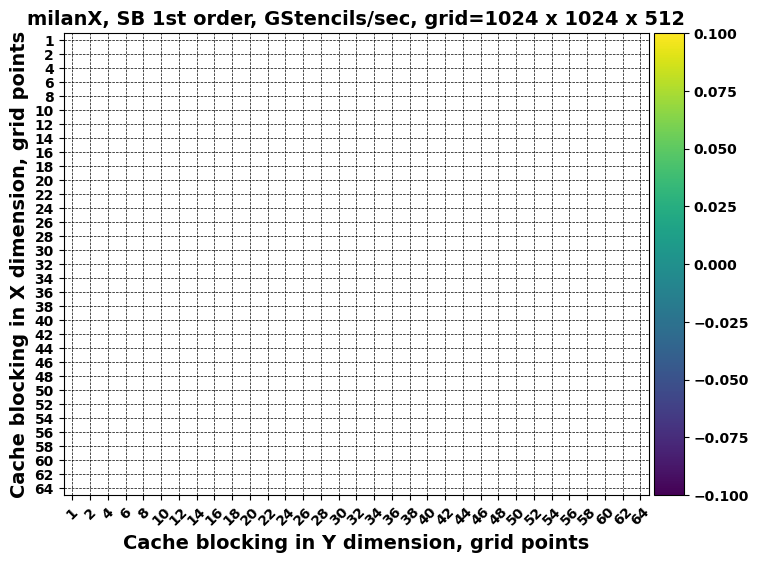

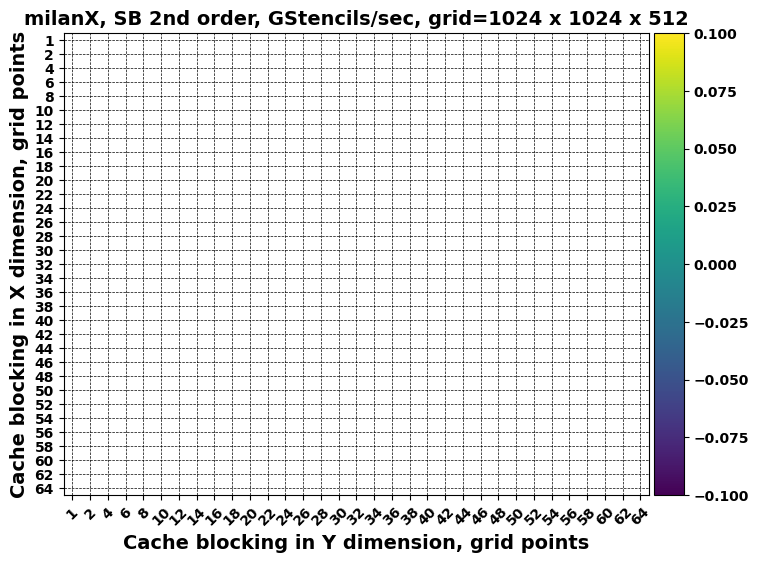

In [25]:
data=read_sb_data(os.path.join(folder_milanX,'test2.log'))   #sb_data
# tb_data=read_sb_data(os.path.join(folder_milanX,'test3.log'))
# data=pd.concat([sb_data,tb_data],ignore_index=True)
data_milanX=data
####################### Create summary for dataframe  #######################
data_summary = data[['method', 'grids', 'times', 'giga_point_s', 'cb_size','cb_x','cb_y','cb_z']]
grid_name='1024 x 1024 x 512'
perf_map_1st = np.ones((ny,nx))*(float('nan'))

####################### Find best parameters for SB 1st order #######################
data_summary_1st = data_summary[data_summary['method'] == 'sb_abc']
data_summary_1st = data_summary_1st[data_summary_1st['grids'] == grid_name]
print(data_summary_1st['grids'].unique())
len(data_summary_1st)

for i in range(len(data_summary_1st)):  # Loops from 0 to 4
    if (data_summary_1st.iloc[i]['grids']==grid_name):
        cb_x_value = data_summary_1st.iloc[i]['cb_x']
        cb_y_value = data_summary_1st.iloc[i]['cb_y']
        x_index = np.where(cbx_val == cb_x_value)[0][0]  # [0][0] gets the first index
        y_index = np.where(cby_val == cb_y_value)[0][0]  # [0][0] gets the first index
        perf_map_1st[y_index,x_index] = data_summary_1st.iloc[i]['giga_point_s']
        if data_summary_1st.iloc[i]['giga_point_s']==-10000:
            aa=1
##################
map_=perf_map_1st
title_='milanX, SB 1st order, GStencils/sec, grid='+grid_name
xlabel_='Cache blocking in Y dimension, grid points'
ylabel_='Cache blocking in X dimension, grid points'
xticks=cbx_val
yticks=cby_val
save_path='milanX_sb_1st_1024.png'
plot_heat_map(map_,title_,xlabel_,ylabel_,xticks,yticks,save_path)

##########################################################################################
##########################################################################################

perf_map_2nd = np.ones((ny,nx))*(float('nan'))
####################### Find best parameters for SB 2nd order #######################
data_summary_2nd = data_summary[data_summary['method'] == 'sb_order2_abc']
data_summary_2nd = data_summary_2nd[data_summary_2nd['grids'] == grid_name]

for i in range(len(data_summary_2nd)):  # Loops from 0 to 4
    if (data_summary_2nd.iloc[i]['grids']==grid_name):
        cb_x_value = data_summary_2nd.iloc[i]['cb_x']
        cb_y_value = data_summary_2nd.iloc[i]['cb_y']
        x_index = np.where(cbx_val == cb_x_value)[0][0]  # [0][0] gets the first index
        y_index = np.where(cby_val == cb_y_value)[0][0]  # [0][0] gets the first index
        perf_map_2nd[y_index,x_index] = data_summary_2nd.iloc[i]['giga_point_s']
        if data_summary_2nd.iloc[i]['giga_point_s']==-10000:
            aa=1
##################
map_=perf_map_2nd
title_='milanX, SB 2nd order, GStencils/sec, grid='+grid_name
xlabel_='Cache blocking in Y dimension, grid points'
ylabel_='Cache blocking in X dimension, grid points'
xticks=cbx_val
yticks=cby_val
save_path='milanX_sb_2nd_1024.png'
plot_heat_map(map_,title_,xlabel_,ylabel_,xticks,yticks,save_path)

# MilanX 512 x 512 x 512

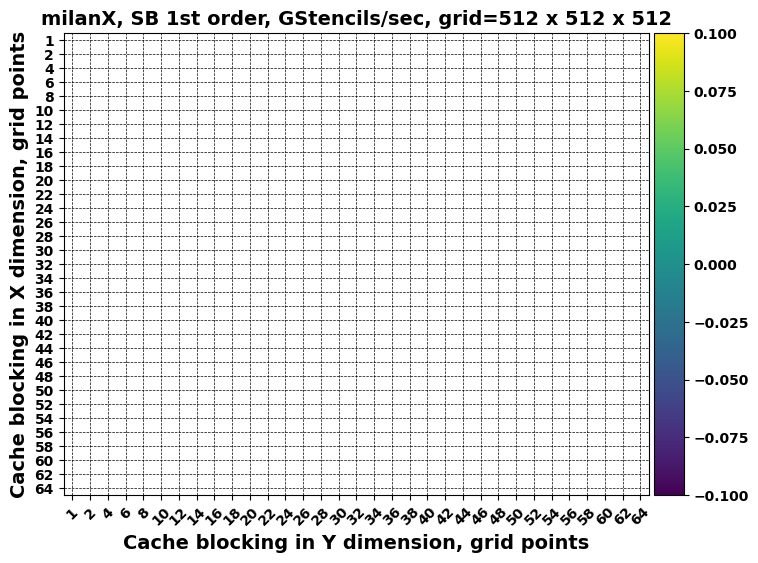

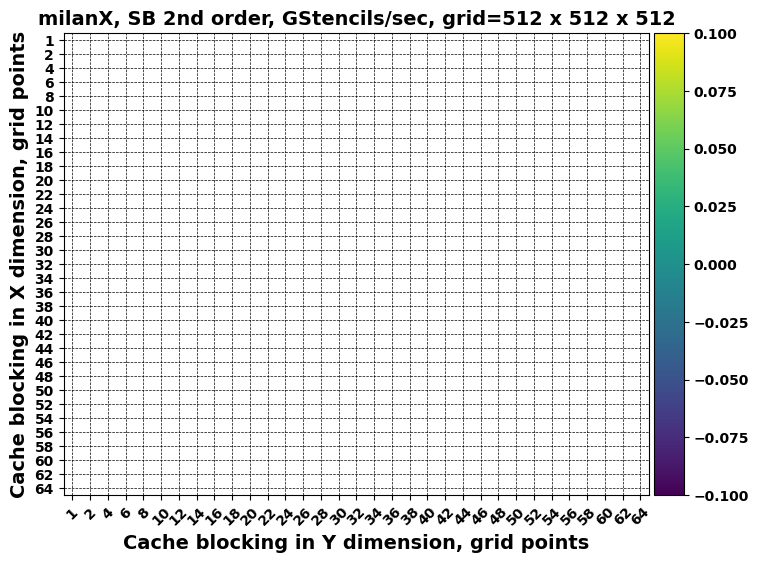

In [23]:
grid_name='512 x 512 x 512'
perf_map_1st = np.ones((ny,nx))*(float('nan'))
####################### Find best parameters for SB 1st order #######################
data_summary_1st = data_summary[data_summary['method'] == 'sb_abc']
data_summary_1st = data_summary_1st[data_summary_1st['grids'] == grid_name]
print(data_summary_1st['grids'].unique())
len(data_summary_1st)

for i in range(len(data_summary_1st)):  # Loops from 0 to 4
    if (data_summary_1st.iloc[i]['grids']==grid_name):
        cb_x_value = data_summary_1st.iloc[i]['cb_x']
        cb_y_value = data_summary_1st.iloc[i]['cb_y']
        x_index = np.where(cbx_val == cb_x_value)[0][0]  # [0][0] gets the first index
        y_index = np.where(cby_val == cb_y_value)[0][0]  # [0][0] gets the first index
        perf_map_1st[y_index,x_index] = data_summary_1st.iloc[i]['giga_point_s']
        if data_summary_1st.iloc[i]['giga_point_s']==-10000:
            aa=1
##################
map_=perf_map_1st
title_='milanX, SB 1st order, GStencils/sec, grid='+grid_name
xlabel_='Cache blocking in Y dimension, grid points'
ylabel_='Cache blocking in X dimension, grid points'
xticks=cbx_val
yticks=cby_val
save_path='milanX_sb_1st_512.png'
plot_heat_map(map_,title_,xlabel_,ylabel_,xticks,yticks,save_path)
########################################################################
perf_map_2nd = np.ones((ny,nx))*(float('nan'))
####################### Find best parameters for SB 2nd order #######################
data_summary_2nd = data_summary[data_summary['method'] == 'sb_order2_abc']
data_summary_2nd = data_summary_2nd[data_summary_2nd['grids'] == grid_name]

for i in range(len(data_summary_2nd)):  # Loops from 0 to 4
    if (data_summary_2nd.iloc[i]['grids']==grid_name):
        cb_x_value = data_summary_2nd.iloc[i]['cb_x']
        cb_y_value = data_summary_2nd.iloc[i]['cb_y']
        x_index = np.where(cbx_val == cb_x_value)[0][0]  # [0][0] gets the first index
        y_index = np.where(cby_val == cb_y_value)[0][0]  # [0][0] gets the first index
        perf_map_2nd[y_index,x_index] = data_summary_2nd.iloc[i]['giga_point_s']
        if data_summary_2nd.iloc[i]['giga_point_s']==-10000:
            aa=1
##################
map_=perf_map_2nd
title_='milanX, SB 2nd order, GStencils/sec, grid='+grid_name
xlabel_='Cache blocking in Y dimension, grid points'
ylabel_='Cache blocking in X dimension, grid points'
xticks=cbx_val
yticks=cby_val
save_path='milanX_sb_2nd_512.png'
plot_heat_map(map_,title_,xlabel_,ylabel_,xticks,yticks,save_path)

In [ ]:
data_turin['arch']='turin'
data_genoaX['arch']='genoaX'
data_genoa['arch']='genoa'
data_milanX['arch']='milanX'
data_milan['arch']='milan'
data_rome['arch']='rome'
data_all=pd.concat([data_turin,data_genoaX,data_genoa,data_milanX,data_milan,data_rome],axis=0,ignore_index=True)

# Extract data for performances graphs

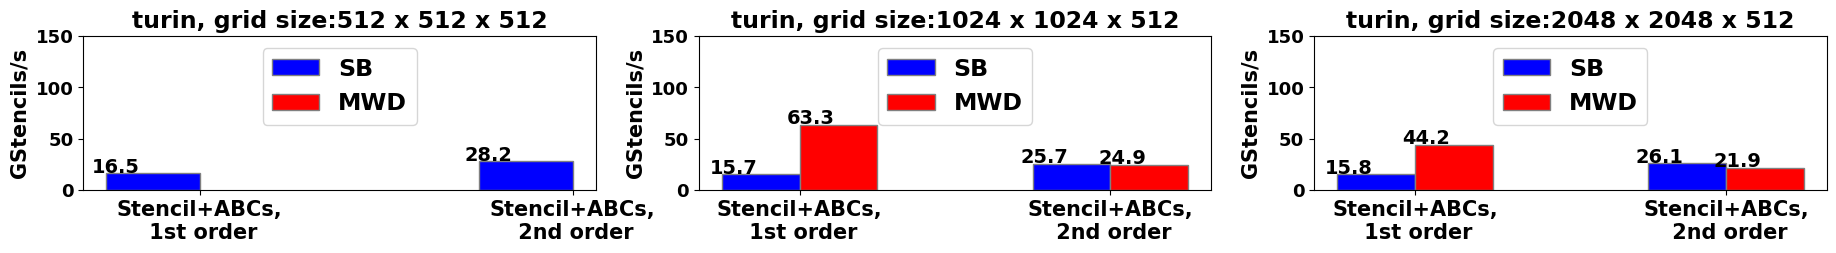

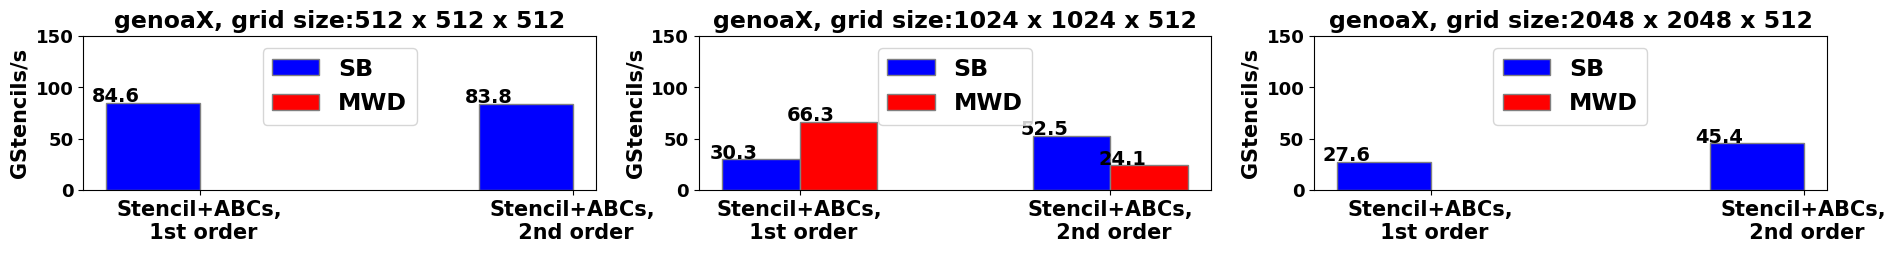

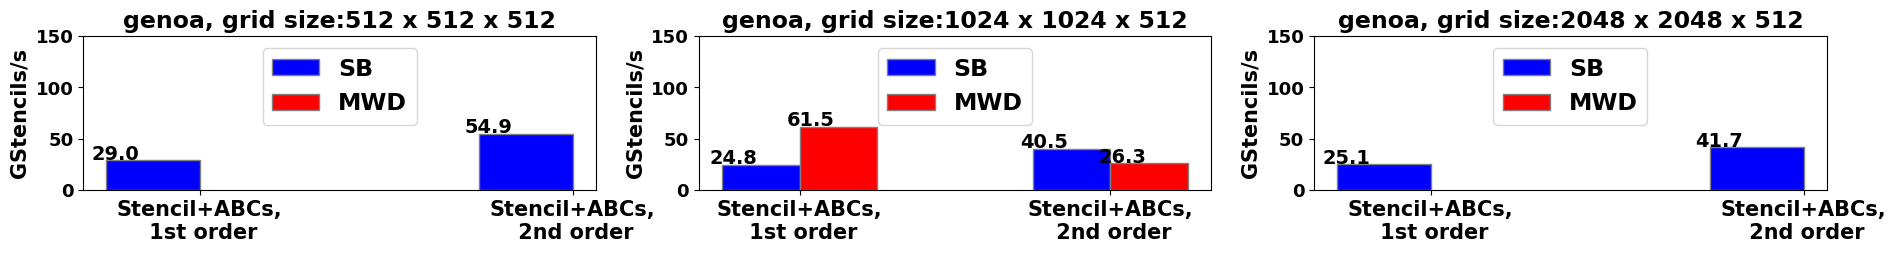

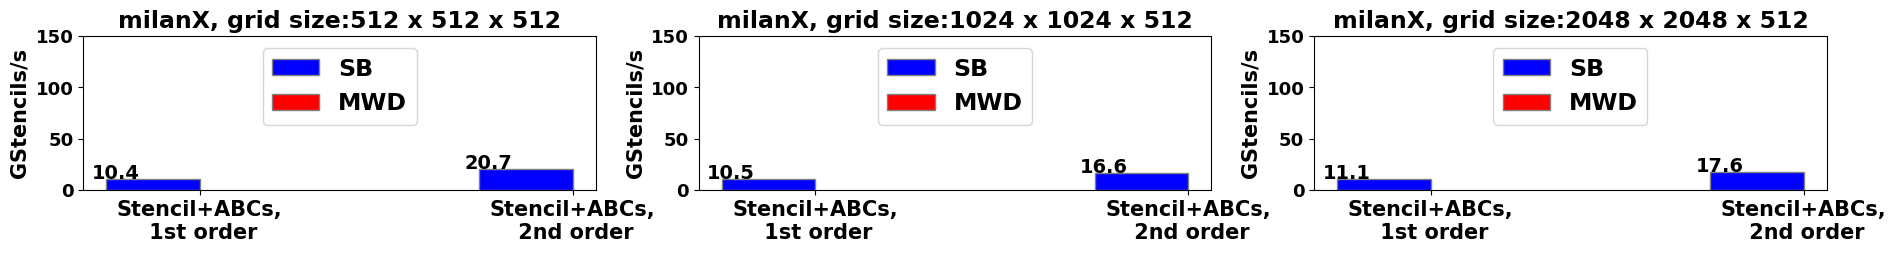

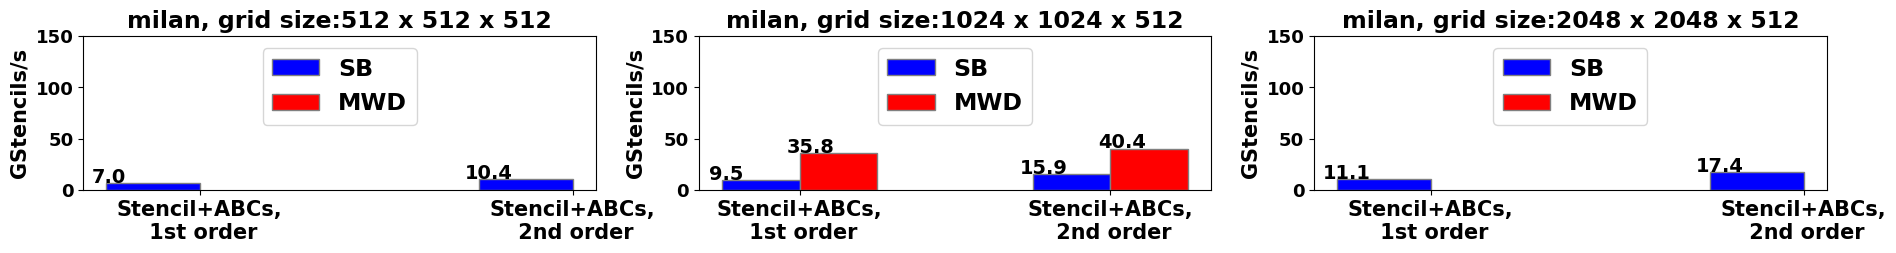

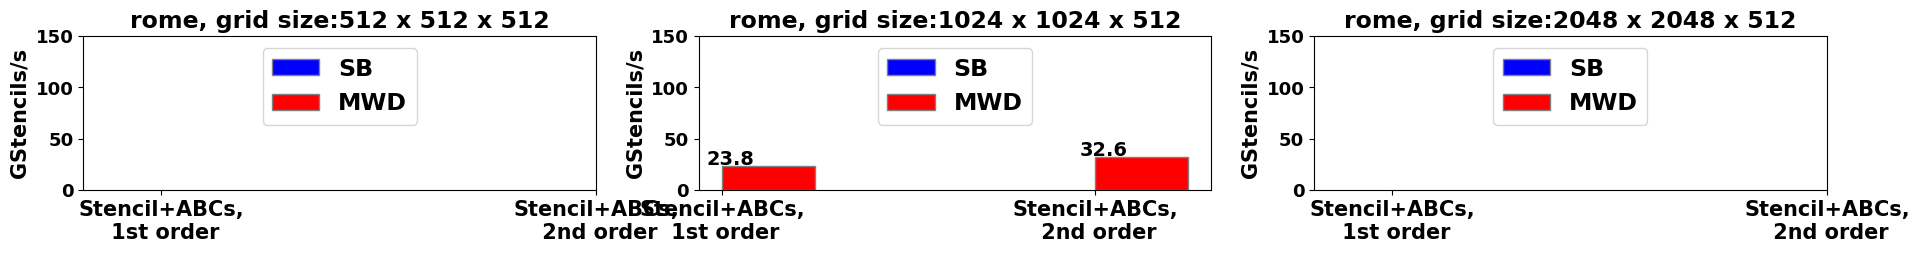

In [ ]:
warnings.filterwarnings("ignore")
sys.stdout = open(os.devnull, 'w')
sys.stdout = sys.__stdout__
####################### Plot bar charts #######################
def plot_perf(data_list,save_paths,title='',metric='gstencils',gflops_limit=3300,gstencils_limit=100):
    barWidth = 0.25
    # fig, ax = plt.subplots(1,len(data_list),figsize=(7.5*len(data_list),5))
    font = {'size': 17};    
    plt.rc('font', **font)
    plt.rcParams["font.weight"]="bold"
    # fig, ax = plt.subplots(1,len(data_list),figsize=(22*len(data_list),2.0))  # first variant
    fig, ax = plt.subplots(1,len(data_list),figsize=(7.5*len(data_list),2.0))  # second variant
    # plt.subplots_adjust(left=0.1, right=0.97,wspace=0.39, hspace=0.4)
    # plt.subplots_adjust(left=0.1, right=0.97,wspace=0.2, hspace=0.5)
    # Set position of bar on X axis 
    br1 = np.arange(2)
    br2 = [x + barWidth for x in br1]
    for (counter,data) in enumerate(data_list):
        print('data=',data)
        grid_name=data[0];
        SB=[data[1],data[3]]; 
        TB=[data[2],data[4]];
        # Make the plot
        if len(data_list)==1:
            AX=ax
        else:
            AX=ax[counter]
        
        bars=AX.bar(br1, SB, color ='b', width = barWidth,edgecolor ='grey', label ='SB')
        for bar in bars:
            yval = bar.get_height()
            if metric=='gflops':
                plot_val=int(yval)
            else:
                plot_val=round(yval,1)
            ### AX.text(bar.get_x()-0.04,yval+yval*0.02,plot_val,fontsize=14,fontweight='bold')   # bold, normal
            if np.isfinite(yval):
                AX.text(bar.get_x() - 0.04, yval + yval * 0.02, plot_val, fontsize=14, fontweight='bold')
            else:
                print(f"Warning: Invalid yval at bar {bar.get_x()}: {yval}")
        
        bars=AX.bar(br2, TB, color ='r', width = barWidth,edgecolor ='grey', label ='MWD')
        for bar in bars:
            yval = bar.get_height()
            if metric=='gflops':
                plot_val=int(yval)
            else:
                plot_val=round(yval,1)
            #### AX.text(bar.get_x()+0.04,yval+yval*0.02,plot_val,fontsize=14,fontweight='bold')
            if np.isfinite(yval):
                AX.text(bar.get_x() - 0.04, yval + yval * 0.02, plot_val, fontsize=14, fontweight='bold')
            else:
                print(f"Warning: Invalid yval at bar {bar.get_x()}: {yval}")

        # AX.set_xticks([r + barWidth for r in range(len(SB))],['Stencil', 'Stencil+ABCs'])
        AX.set_xticks([0.125,1.125],['Stencil+ABCs,\n 1st order','Stencil+ABCs,\n 2nd order'], fontweight ='bold', fontsize = 15)
        # AX.set_yticks(fontsize=15)
        # plt.yticks(fontsize=13)
        AX.tick_params(axis='y', labelsize=13)

        if metric=='gflops':
            AX.set_ylabel('GFlop/s', fontweight ='bold', fontsize = 15)
            AX.set_ylim(bottom=0,top=gflops_limit)
        else:
            # AX.set_ylabel('GStencils/s', fontweight ='bold', fontsize = 18)
            AX.set_ylabel('GStencils/s', fontweight ='bold', fontsize = 15)
            AX.set_ylim(bottom=0,top=gstencils_limit)
        # AX.legend(loc='upper right')
        # AX.legend(loc='upper left')
        AX.legend(loc='upper center')
        # AX.set_title('Grid size:\n'+grid_name,fontweight='bold',fontsize=14)
        AX.set_title(title+', grid size:'+grid_name,fontweight='bold',fontsize=17)
    my_suptitle=fig.suptitle('',fontsize=18,y=0,weight='bold')
    # my_suptitle=fig.suptitle(title,fontsize=18,y=0,weight='bold')
    plt.show()
    fig.savefig(save_paths[0]+'.png',bbox_inches='tight',bbox_extra_artists=[my_suptitle])
    fig.savefig(save_paths[0]+'.pdf',bbox_inches='tight',bbox_extra_artists=[my_suptitle])
    return None

###########################################################################
data_list=[]
# extract sb tb vals for all archs and grids
archs=data_all['arch'].unique()
# print(data_all['grids'].unique())
metric='giga_point_s'
for arch in archs:
    # print(arch)
    data_ = data_all[data_all['arch'] == arch]
    data_list=[]
    for grid in grids_:
        data_list_=[]
        # print(arch,grid)
        data_grid=data_[data_['grids'] == grid]
        # choose code type
        data_grid_sb_abc=data_grid[data_grid['method']=='sb_abc']
        data_grid_tb_abc=data_grid[data_grid['method']=='tb_abc']
        data_grid_sb_order2_abc=data_grid[data_grid['method']=='sb_order2_abc']
        data_grid_tb_order2_abc=data_grid[data_grid['method']=='tb_order2_abc']
        # sort results by performance
        data_grid_sb_abc=data_grid_sb_abc.sort_values(by=[metric],ascending=False)
        data_grid_tb_abc=data_grid_tb_abc.sort_values(by=[metric],ascending=False)
        data_grid_sb_order2_abc=data_grid_sb_order2_abc.sort_values(by=[metric],ascending=False)
        data_grid_tb_order2_abc=data_grid_tb_order2_abc.sort_values(by=[metric],ascending=False)
        #########################
        ##### record 1st order results
        if len(data_grid_sb_abc[metric].values)!=0:
            sb_abc_val=data_grid_sb_abc[metric].values[0]
        else:
            sb_abc_val=math.nan
        if len(data_grid_tb_abc[metric].values)!=0:
            tb_abc_val=data_grid_tb_abc[metric].values[0]
        else:
            tb_abc_val=math.nan
        ##### record 2nd order results
        if len(data_grid_sb_order2_abc[metric].values)!=0:
            sb_order2_abc_val=data_grid_sb_order2_abc[metric].values[0]
        else:
            sb_order2_abc_val=math.nan
        if len(data_grid_tb_order2_abc[metric].values)!=0:
            tb_order2_abc_val=data_grid_tb_order2_abc[metric].values[0]
        else:
            tb_order2_abc_val=math.nan
        data_list_=[grid,sb_abc_val,tb_abc_val,sb_order2_abc_val,tb_order2_abc_val]
        print(data_list_)
        data_list.append(data_list_)
    ########################
    save_paths=['./'+arch+'_gstencils']
    plot_perf(data_list,save_paths,title=arch,metric='gstencils',gstencils_limit=150)
    print(data_list[-1])



In [ ]:
# !cp *.png* /home/plotnips/Dropbox/Apps/Overleaf/2025_01_stencil_report/figures/performances